# 02 — Global Risk Regime

**Chain position:** Macro → `Risk` → Rates → Global Equity → India → Companies

Notebook 01 established what the economy is doing. This one asks a different and more
immediate question: **how is the market pricing risk right now?**

The two can disagree, and the disagreement is the signal. A healthy economy with a
market paying up for protection is a market that expects the economy to stop being
healthy.

Four volatility surfaces are read together, because each prices a different fear:

| Gauge | Prices the fear of | Why it matters here |
|---|---|---|
| **VIX** | Equity drawdown | The headline risk gauge |
| **MOVE** | Rate volatility | Bond stress leads equity stress |
| **OVX** | Oil volatility | Energy shock risk — direct India CPI input |
| **SKEW** | Tail / crash risk | High SKEW = cheap insurance being bought |
| **VVIX** | Volatility of volatility | How unstable the fear itself is |

Bitcoin is included as a pure risk-appetite proxy — and it is the reason this notebook
is careful. **BTC trades 7 days a week; equities trade 5.** Joining them naively forces
a calendar-day index and injects ~32% spurious NaNs into every equity series. That is
handled explicitly below rather than assumed away.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_root = Path.cwd()
while not (_root / "mkt").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mkt
from mkt import (config, cache, fetch, align, dashboard,
                 indicators as ind, fundamentals as fnd, score, viz)

# Set REFRESH = True to force a live re-fetch of every source, ignoring the cache.
REFRESH = False
mkt.bootstrap(refresh=REFRESH)

mkt v1.0.0 | run 2026-09-09 10:45 | REFRESH=False | cache=G:\stock market analysis\data\cache


## 1. The volatility complex

Levels alone say little — VIX at 18 is calm in one decade and alarming in another. What
matters is where each gauge sits **in its own 10-year distribution**, so every gauge is
converted to a percentile rank.

In [2]:
vol_frames, vol_failed = fetch.price_histories(
    list(config.RISK_TICKERS), period=config.LONG_HISTORY_PERIOD)
if vol_failed:
    print("Dropped (reported, not hidden):", vol_failed)
    print("  -> ^VIX failed once during source testing and worked on retry;")
    print("     that is exactly why every fetch is wrapped in backoff.")

vol = align.align_multi(vol_frames, calendar="NYSE", max_gap=3)
vol.columns = [config.RISK_TICKERS.get(c, c) for c in vol.columns]
rate = align.assert_alignment(vol, max_nan_pct=8.0, label="volatility complex")
print(f"Post-alignment NaN rate: {rate}%  (trap #1 guard passed)")
display(align.describe_asof(vol))

  fetched 5/5 tickers in 5s


Post-alignment NaN rate: 0.01%  (trap #1 guard passed)


,series,as_of,value,lag_days
0,VIX (equity vol),2026-09-08,15.72,0
1,MOVE (bond vol),2026-09-08,76.14,0
2,OVX (oil vol),2026-09-08,48.59,0
3,SKEW (tail risk),2026-09-08,148.86,0
4,VVIX (vol of vol),2026-09-08,88.69,0


,level,as_of,chg_1m,pctile_10y,z_10y,median_10y
gauge,,,,,,
VIX (equity vol),15.72,2026-09-08,0.82,39.13,-0.40,16.91
MOVE (bond vol),76.14,2026-09-08,4.11,54.92,-0.13,72.08
OVX (oil vol),48.59,2026-09-08,-7.21,82.38,0.40,35.92
SKEW (tail risk),148.86,2026-09-08,16.29,85.36,1.03,136.35
VVIX (vol of vol),88.69,2026-09-08,-1.73,26.07,-0.70,96.95


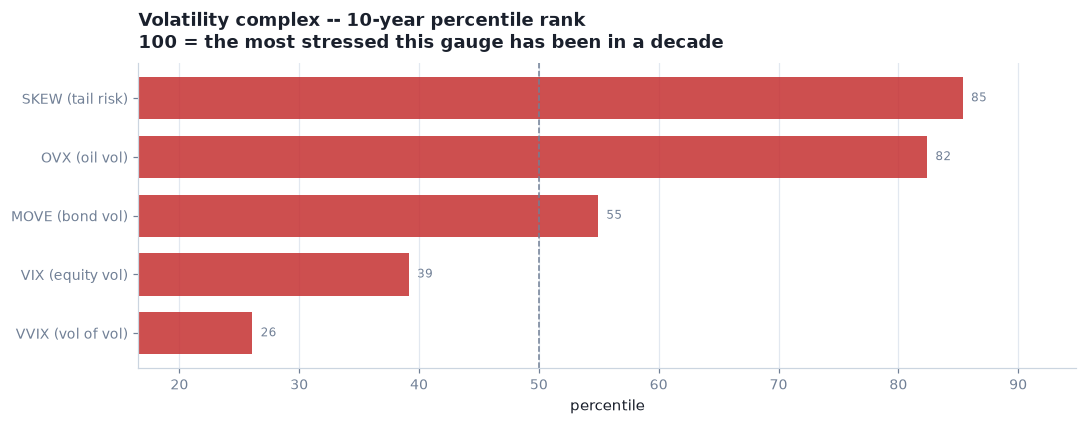

In [3]:
vol_state = []
for c in vol.columns:
    s = vol[c].dropna()
    if s.empty:
        continue
    hist = s.tail(2520)
    vol_state.append({
        "gauge": c,
        "level": float(s.iloc[-1]),
        "as_of": s.index[-1].date(),
        "chg_1m": float(s.iloc[-1] - s.iloc[max(0, len(s) - 22)]),
        "pctile_10y": ind.percentile_rank(hist),
        "z_10y": float((s.iloc[-1] - hist.mean()) / hist.std()),
        "median_10y": float(hist.median()),
    })
vol_state = pd.DataFrame(vol_state).set_index("gauge")
display(vol_state.round(2))

fig, ax = plt.subplots(figsize=(11, 3.6))
viz.ranked_bar(vol_state["pctile_10y"], ax=ax,
               title_="Volatility complex -- 10-year percentile rank",
               sub="100 = the most stressed this gauge has been in a decade",
               xlabel="percentile", positive_is_good=False, fmt="{:.0f}")
ax.axvline(50, color=viz.MUTED, ls="--", lw=1)
viz.save(fig, "02_vol_percentiles"); plt.show()

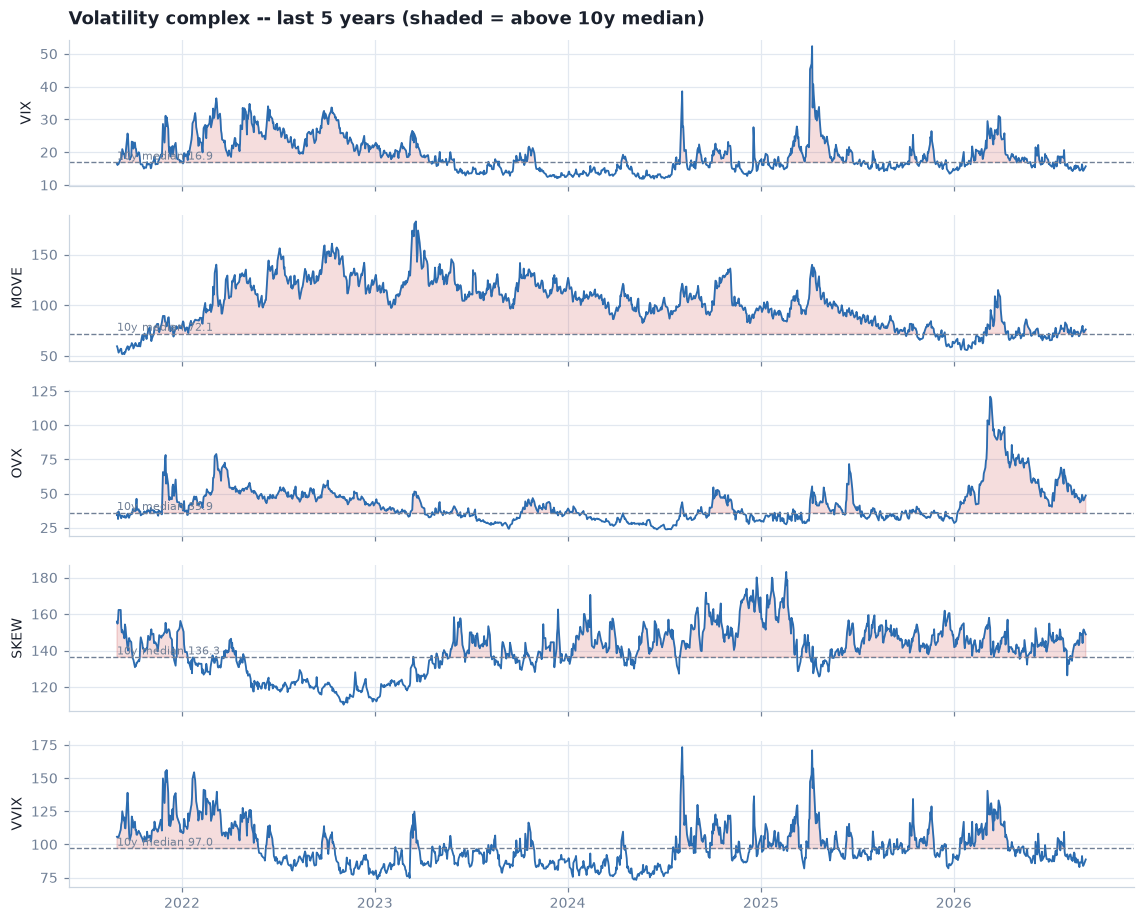

In [4]:
show = vol.tail(1260)
fig, axes = plt.subplots(len(show.columns), 1, figsize=(12.5, 2.0 * len(show.columns)),
                         sharex=True)
for axi, c in zip(np.atleast_1d(axes), show.columns):
    s = show[c].dropna()
    axi.plot(s.index, s.values, color=viz.PALETTE[0], lw=1.2)
    med = float(vol[c].tail(2520).median())
    axi.axhline(med, color=viz.MUTED, ls="--", lw=0.9)
    axi.fill_between(s.index, med, s.values, where=(s.values > med),
                     color=viz.NEG, alpha=0.16, interpolate=True)
    axi.set_ylabel(c.split(" (")[0], fontsize=9)
    axi.annotate(f"10y median {med:,.1f}", xy=(s.index[0], med), fontsize=7.5,
                 color=viz.MUTED, va="bottom")
np.atleast_1d(axes)[0].set_title("Volatility complex -- last 5 years (shaded = above 10y median)",
                                 loc="left")
viz.save(fig, "02_vol_complex"); plt.show()

## 2. Trap #1, demonstrated

Bitcoin is the cleanest available proxy for speculative risk appetite, and it is also
the thing that breaks naive cross-market joins. Below, the same data is assembled twice:
once the wrong way, once the right way. The measurement is printed, not asserted.

In [5]:
risk_assets, ra_failed = fetch.price_histories(
    list(config.RISK_ASSETS) + list(config.CRYPTO_TICKERS),
    period=config.LONG_HISTORY_PERIOD)
if ra_failed:
    print("Dropped:", ra_failed)

# --- the wrong way: everything joined on a union calendar, BTC included ---
naive = fetch.close_frame(risk_assets)
naive_nan = align.nan_rate(naive)

# --- the right way: equities on the NYSE calendar; BTC aligned onto it deliberately ---
eq_only = {k: v for k, v in risk_assets.items() if k not in config.CRYPTO_TICKERS}
risk_px = align.align_multi(eq_only, calendar="NYSE", max_gap=3)
btc = align.align_to_calendar(
    fetch.close_frame({k: v for k, v in risk_assets.items() if k in config.CRYPTO_TICKERS}),
    calendar=pd.DatetimeIndex(risk_px.index), max_gap=3)
risk_px = risk_px.join(btc, how="left")
clean_nan = align.nan_rate(risk_px)

print(f"Naive union join (BTC 7-day + equities 5-day) : {naive_nan:>6.2f}% NaN")
print(f"Deliberate alignment onto the NYSE calendar   : {clean_nan:>6.2f}% NaN")
print(f"Spurious NaNs removed                         : {naive_nan - clean_nan:>6.2f} pp")
align.assert_alignment(risk_px, max_nan_pct=8.0, label="risk assets")

risk_px.columns = [{**config.RISK_ASSETS, **config.CRYPTO_TICKERS}.get(c, c)
                   for c in risk_px.columns]
display(align.coverage_report(risk_px))

  fetched 8/8 tickers in 2s
Naive union join (BTC 7-day + equities 5-day) :  19.52% NaN
Deliberate alignment onto the NYSE calendar   :   0.00% NaN
Spurious NaNs removed                         :  19.52 pp


,series,first_obs,last_obs,n_obs,n_slots,nan_pct_in_window,max_gap_days,lag_days
0,S&P 500,2006-09-11,2026-09-08,5029,5029,0.00,5,0
1,Gold,2006-09-11,2026-09-08,5029,5029,0.00,5,0
2,Copper,2006-09-11,2026-09-08,5029,5029,0.00,5,0
3,US Dollar Index,2006-09-11,2026-09-08,5029,5029,0.00,5,0
4,US 20y+ Treasuries,2006-09-11,2026-09-08,5029,5029,0.00,5,0
5,US High Yield,2007-04-11,2026-09-08,4884,4884,0.00,5,0
6,US Investment Grade,2006-09-11,2026-09-08,5029,5029,0.00,5,0
7,Bitcoin,2014-09-17,2026-09-08,3011,3011,0.00,4,0


## 3. Drawdowns — how much damage is already done

Percentile ranks describe fear. Drawdowns describe damage. A market can be calm and
deeply underwater at the same time, and that combination is different from calm at
all-time highs.

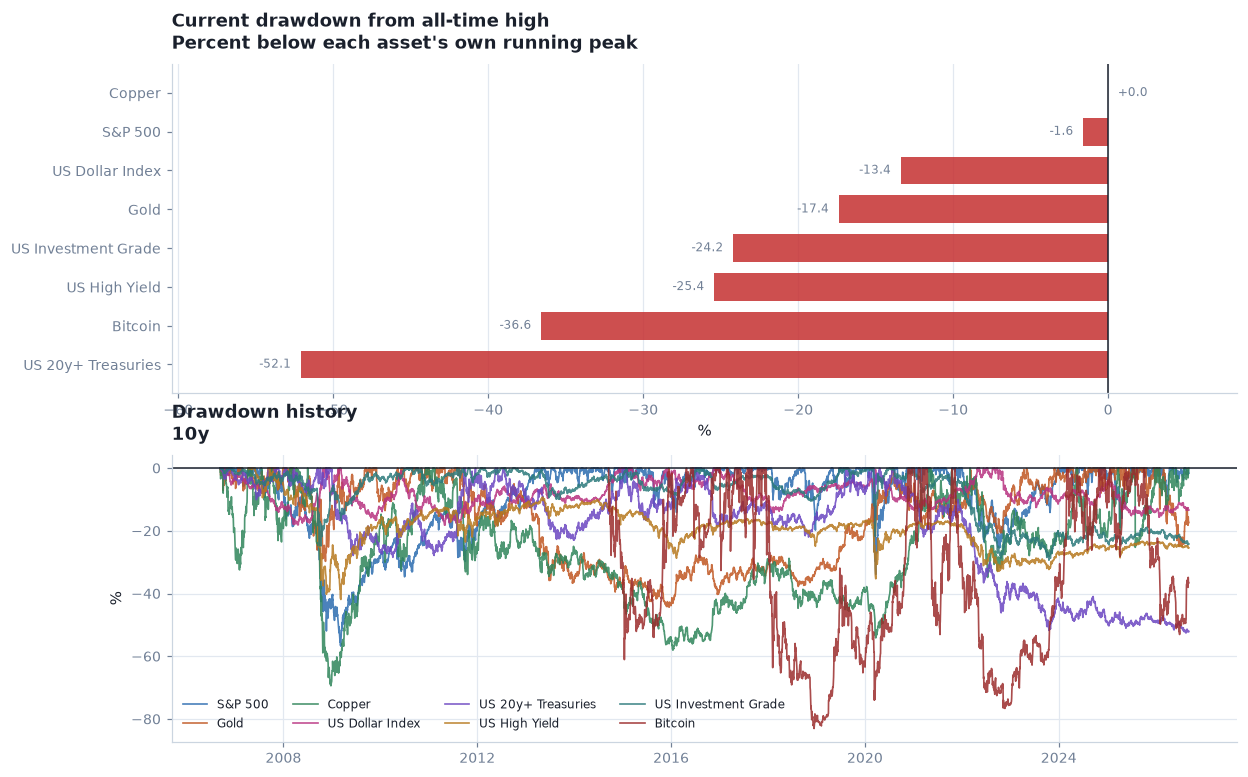

,current_dd_%,max_dd_%,as_of
US 20y+ Treasuries,-52.09,-52.58,2026-09-08
Bitcoin,-36.58,-83.04,2026-09-08
US High Yield,-25.42,-41.90,2026-09-08
US Investment Grade,-24.20,-29.37,2026-09-08
Gold,-17.38,-44.36,2026-09-08
US Dollar Index,-13.38,-18.16,2026-09-08
S&P 500,-1.61,-56.78,2026-09-08
Copper,0.00,-69.41,2026-09-08


In [6]:
dd = pd.DataFrame({c: ind.drawdown(risk_px[c].dropna()) for c in risk_px.columns})
dd_now = dd.ffill().iloc[-1].dropna().sort_values()

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12.5, 8),
                             gridspec_kw={"height_ratios": [1.15, 1]})
viz.ranked_bar(dd_now, ax=a1, title_="Current drawdown from all-time high",
               sub="Percent below each asset's own running peak",
               xlabel="%", positive_is_good=True)
for c in dd.columns:
    a2.plot(dd.index, dd[c], lw=1.1, label=c, alpha=0.85)
a2.axhline(0, color=viz.INK, lw=1)
viz.title(a2, "Drawdown history", f"{config.RISK_LOOKBACK_YEARS}y")
a2.legend(ncol=4, fontsize=8); a2.set_ylabel("%")
viz.save(fig, "02_drawdowns"); plt.show()

display(pd.DataFrame({
    "current_dd_%": dd_now,
    "max_dd_%": {c: ind.max_drawdown(risk_px[c].dropna()) for c in dd_now.index},
    "as_of": {c: risk_px[c].last_valid_index().date() for c in dd_now.index},
}).round(2))

## 4. Is diversification actually working?

The correlation matrix is the honest test. Correlations are computed **after** alignment
on daily returns — computing them on an unaligned frame silently pairs a Tuesday with a
Wednesday and produces numbers that look fine and mean nothing.

The rolling view matters more than the static one: correlations converge exactly when
diversification is most needed.

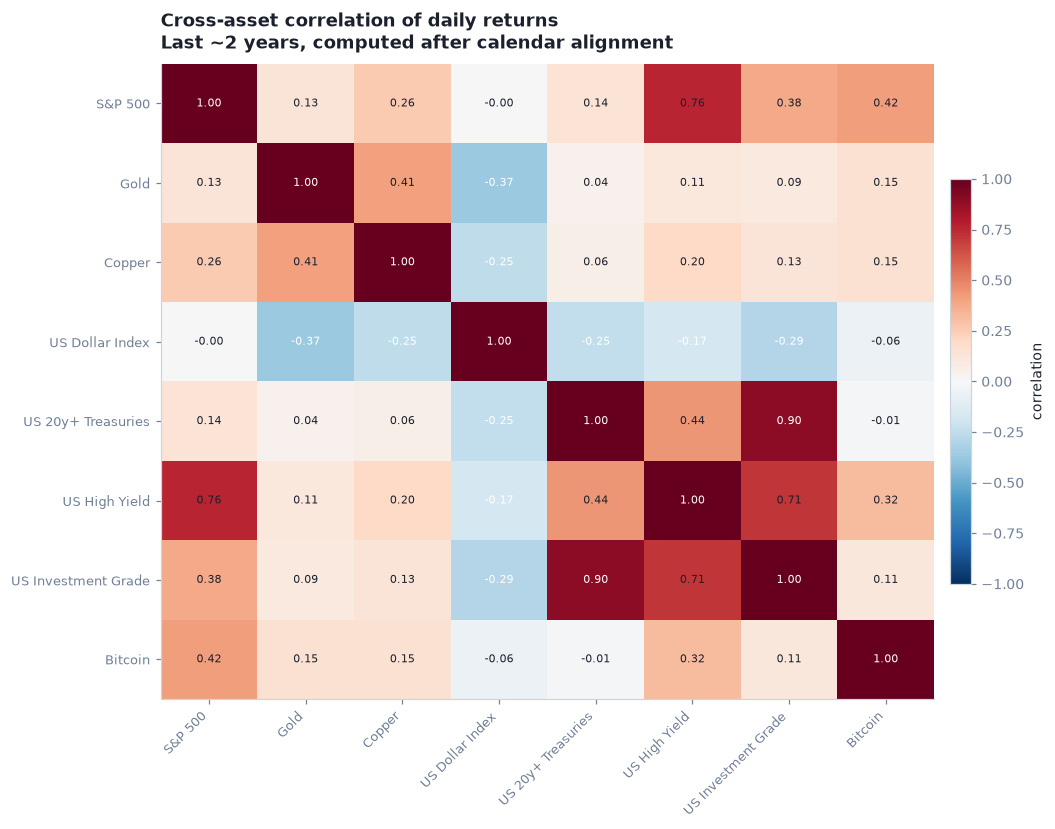

Average pairwise correlation: +0.161
High and rising average correlation means the portfolio is really one bet.


In [7]:
rets = align.to_returns(risk_px).dropna(how="all")
window = rets.tail(504)                      # ~2 years of daily returns
corr = window.corr()

fig, ax = plt.subplots(figsize=(9.5, 7.5))
viz.heatmap(corr, ax=ax, cmap="RdBu_r", vmin=-1, vmax=1, fmt="{:.2f}",
            title_="Cross-asset correlation of daily returns",
            sub="Last ~2 years, computed after calendar alignment",
            cbar_label="correlation")
viz.save(fig, "02_correlation"); plt.show()

avg_corr = (corr.where(~np.eye(len(corr), dtype=bool)).stack().mean())
print(f"Average pairwise correlation: {avg_corr:+.3f}")
print("High and rising average correlation means the portfolio is really one bet.")

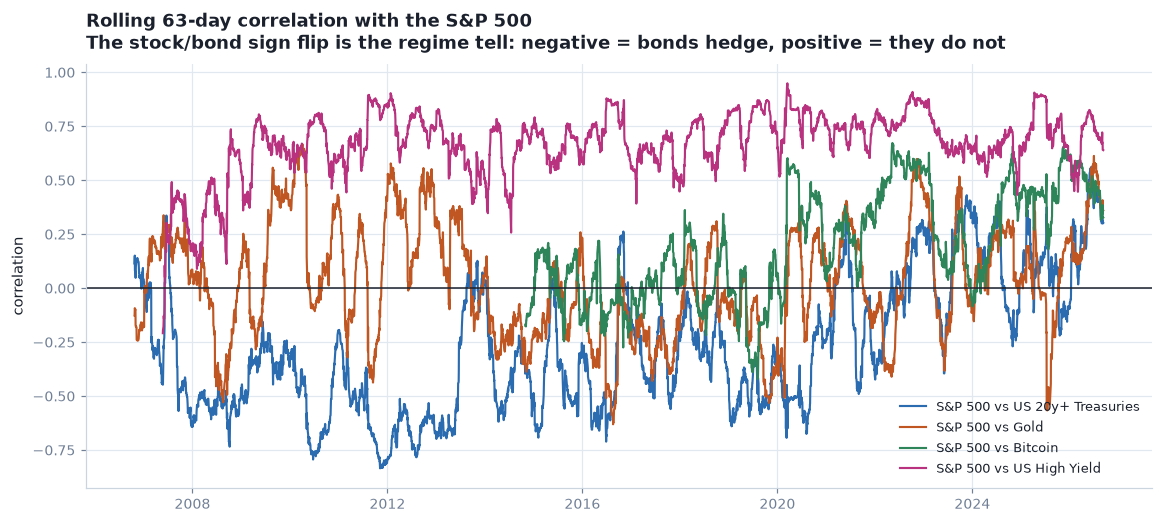

Stock/bond 63d correlation now: +0.30 (bonds are NOT hedging equities)


In [8]:
pairs = [("S&P 500", "US 20y+ Treasuries"), ("S&P 500", "Gold"),
         ("S&P 500", "Bitcoin"), ("S&P 500", "US High Yield")]
pairs = [(a, b) for a, b in pairs if a in risk_px.columns and b in risk_px.columns]

fig, ax = plt.subplots(figsize=(12.5, 5))
for a, b in pairs:
    rc = ind.rolling_corr(rets[a], rets[b], window=63)
    ax.plot(rc.index, rc.values, lw=1.4, label=f"{a} vs {b}")
ax.axhline(0, color=viz.INK, lw=1)
viz.title(ax, "Rolling 63-day correlation with the S&P 500",
          "The stock/bond sign flip is the regime tell: negative = bonds hedge, positive = they do not")
ax.legend(fontsize=8.5); ax.set_ylabel("correlation")
viz.save(fig, "02_rolling_corr"); plt.show()

if ("S&P 500", "US 20y+ Treasuries") in [(a, b) for a, b in pairs]:
    sb = ind.rolling_corr(rets["S&P 500"], rets["US 20y+ Treasuries"], 63).dropna()
    print(f"Stock/bond 63d correlation now: {float(sb.iloc[-1]):+.2f} "
          f"({'bonds are hedging equities' if sb.iloc[-1] < 0 else 'bonds are NOT hedging equities'})")

## 5. Composite risk score

Six inputs, each z-scored against its own 10-year history and signed so that **positive
= risk-on**:

- VIX, MOVE, OVX — inverted (high volatility is risk-off)
- SKEW — inverted (crash insurance being bid is risk-off)
- Gold/copper — inverted (a bid for gold over copper is fear)
- High yield vs investment grade — credit's own verdict on risk appetite

The score is the mean of whichever inputs are available, so a missing gauge degrades the
score's confidence rather than silently dropping to zero.

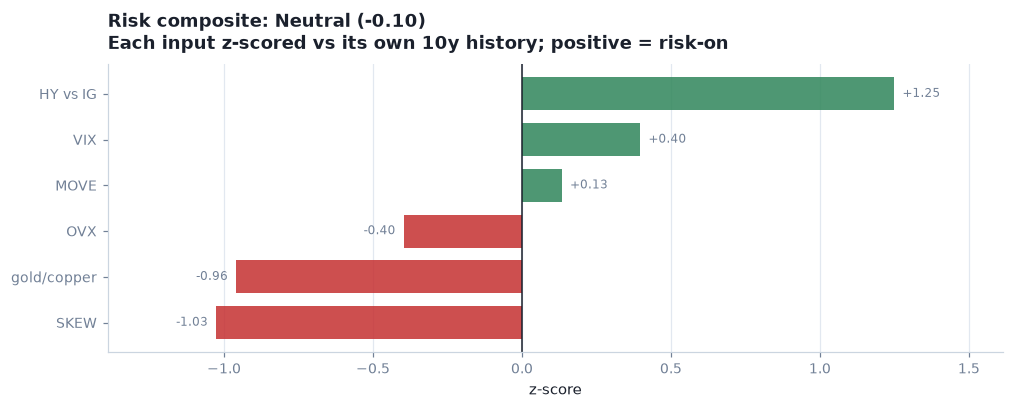

,z_score
VIX,0.40
MOVE,0.13
OVX,-0.40
SKEW,-1.03
gold/copper,-0.96
HY vs IG,1.25



Inputs available: 6 of 6
RISK REGIME: Neutral  (composite z = -0.10)


In [9]:
def z10(s):
    s = s.dropna()
    hist = s.tail(2520)
    if len(hist) < 100 or hist.std() == 0:
        return np.nan
    return float((s.iloc[-1] - hist.mean()) / hist.std())

comp = {}
for name, col in [("VIX", "VIX (equity vol)"), ("MOVE", "MOVE (bond vol)"),
                  ("OVX", "OVX (oil vol)"), ("SKEW", "SKEW (tail risk)")]:
    if col in vol.columns:
        comp[name] = -z10(vol[col])          # inverted: high vol = risk-off

if {"Gold", "Copper"} <= set(risk_px.columns):
    comp["gold/copper"] = -z10(risk_px["Gold"] / risk_px["Copper"])
if {"US High Yield", "US Investment Grade"} <= set(risk_px.columns):
    comp["HY vs IG"] = z10(risk_px["US High Yield"] / risk_px["US Investment Grade"])

comp_s = pd.Series(comp).dropna()
risk_score = float(comp_s.mean())
label = ("Risk-On" if risk_score >= 0.5 else
         "Risk-Off" if risk_score <= -0.5 else "Neutral")

fig, ax = plt.subplots(figsize=(10.5, 3.4))
viz.ranked_bar(comp_s, ax=ax, title_=f"Risk composite: {label} ({risk_score:+.2f})",
               sub="Each input z-scored vs its own 10y history; positive = risk-on",
               xlabel="z-score", fmt="{:+.2f}")
viz.save(fig, "02_risk_composite"); plt.show()

display(comp_s.to_frame("z_score").round(2))
print(f"\nInputs available: {len(comp_s)} of 6")
print(f"RISK REGIME: {label}  (composite z = {risk_score:+.2f})")

In [10]:
macro_prev = dashboard.read().get("01_macro", {})
print(f"Notebook 01 said : {macro_prev.get('signal', '(not run yet)')}")
print(f"Notebook 02 says : {label} ({risk_score:+.2f})")
print()
if macro_prev:
    nowcast = macro_prev.get("nowcast", {}).get("label", "")
    if nowcast == "Expansionary" and risk_score < -0.5:
        print("DIVERGENCE: macro nowcast is expansionary but the market is paying for protection.")
    elif nowcast == "Contractionary" and risk_score > 0.5:
        print("DIVERGENCE: macro nowcast is contractionary but the market is positioned for risk.")
    else:
        print("Macro nowcast and market risk pricing are broadly consistent.")

payload = {
    "signal": label,
    "score": round(risk_score, 3),
    "as_of": str(risk_px.index.max().date()),
    "components": {k: round(float(v), 3) for k, v in comp_s.items()},
    "vol_percentiles": {c: round(float(vol_state.loc[c, "pctile_10y"]), 1)
                        for c in vol_state.index},
    "vol_levels": {c: round(float(vol_state.loc[c, "level"]), 2) for c in vol_state.index},
    "avg_pairwise_corr": round(float(avg_corr), 3),
    "drawdowns_%": {c: round(float(v), 2) for c, v in dd_now.items()},
    "nan_rate_naive_%": round(float(naive_nan), 2),
    "nan_rate_aligned_%": round(float(clean_nan), 2),
}
dashboard.append("02_risk", payload)
display(dashboard.summary())

Notebook 01 said : Goldilocks (growth, cooling prices) | nowcast: Mixed
Notebook 02 says : Neutral (-0.10)

Macro nowcast and market risk pricing are broadly consistent.


,notebook,signal,score,as_of,updated_at
0,01_macro,"Goldilocks (growth, cooling prices) | nowcast:...",0.00,2026-09-09,2026-09-09 05:15:44
1,02_risk,Neutral,-0.10,2026-09-08,2026-09-09 05:16:16
2,03_rates,Cautious on duration,-0.23,2026-09-04,2026-09-08 11:47:21
3,04_global_equity,India lagging the world,-38.36,2026-09-08,2026-09-08 11:47:51
4,05_india_market,Mixed,0.23,2026-09-08 15:30:00,2026-09-08 11:48:30
5,06_india_companies,"Top 8 of 50 screened, 6 sectors",81.12,2026-09-08,2026-09-08 11:54:03
6,07_signal_validation,Technical leg: Not proven,-1.62,2026-09-09,2026-09-09 04:42:58
7,08_earnings_quality,"7 do-not-own, 8 short candidates, 43 names pass",51.32,2026-03-31,2026-09-09 04:49:04
8,09_positioning,"12 names scored, 6 short candidates checked fo...",54.69,2026-09-09,2026-09-09 05:12:38
9,10_portfolio,"6L / 5S, gross 1.01x, net -0.13x",7.25,2026-09-09,2026-09-09 05:01:54


## What this hands to notebook 03

The risk score above is a *market-priced* view of stress. Notebook 03 goes to the
instrument that usually moves first — the bond market — and reads the full US Treasury
curve, its slope and inversion history, and the India–US spread.

MOVE appears in both notebooks deliberately: here as one input to risk appetite, there
as the rate-volatility regime that governs how much to trust any duration signal.